# Ghana LEAP 1000 — DiD Estimation

> *Ghana Livelihood Empowerment Against Poverty (LEAP) 1000 Impact Evaluation*  
> Institute of Statistical, Social & Economic Research (ISSER), University of Ghana, Legon.

---

## Programme

**LEAP 1000** is a government cash-transfer programme targeting extremely poor households with children aged 0–1.  Implemented by Ghana's Department of Social Welfare, it provides quarterly transfers to improve household welfare and break intergenerational poverty.

The impact evaluation uses a **cluster-randomised controlled trial (RCT)**:

| Design element | Detail |
|---|---|
| Trial regions | Northern & Upper East Ghana |
| Trial districts | 5 (East Mamprusi, Karaga, Yendi, Bongo, Garu-Tempane) |
| Randomisation unit | Sub-district community / cluster |
| Waves | Baseline 2015, Endline 2017 |
| Primary outcome | Adult-equivalent household expenditure / month (constant GH₵) |

**Goal of this notebook**: estimate and interpret the DiD effect of LEAP 1000 on household expenditure, and clarify what causal quantity it identifies (ITT vs ATT).

In [1]:
import warnings; warnings.filterwarnings('ignore')
import sys; sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from src.apps.ghana.data      import load_data, W_ALL, W_LABELS, NUMERIC_W, BINARY_W
from src.apps.ghana.analysis  import naive_did, regression_did, balance_tests
from src.apps.ghana.visualize import plot_ghana_map, plot_love, plot_parallel_trends

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
DATA_DIR = '../data/ghana'
TREAT_COLOR, CTRL_COLOR = '#e07b39', '#5b8db8'

df  = load_data(DATA_DIR)
df0 = df[df['wave'] == 0].copy()   # baseline only
df1 = df[df['wave'] == 1].copy()   # endline only

n_base, n_end = len(df0), len(df1)
print(f'Observations  : {len(df):,}  ({n_base:,} baseline · {n_end:,} endline)')
print(f'Treated (T=1) : {df0["T"].sum():,} / {n_base:,} at baseline')
print(f'Regions       : {dict(df["region"].value_counts())}')

RESULTS_DIR = Path('../results/ghana')
MAP_DIR = RESULTS_DIR / 'map'
MAP_DIR.mkdir(parents=True, exist_ok=True)

Observations  : 4,828  (2,497 baseline · 2,331 endline)
Treated (T=1) : 1,262 / 2,497 at baseline
Regions       : {'Northern': np.int64(3281), 'Upper East': np.int64(1547)}


## Study area

The trial was conducted across five districts in Ghana's Northern and Upper East regions — among the country's poorest areas.  Both Treatment and Comparison households appear within every district (T rate ≈ 50%), confirming that randomisation operated below the district level.

The dataset contains **162 community identifiers** (`comm`) with GPS centroids (all households in the same community share one coordinate).  Three communities — comm 14 (Garu-Tempane), 273 (Karaga), 281 (East Mamprusi) — have no GPS recorded in the source data, covering **151 rows (3.1% of the dataset)**.  These same communities also show high panel attrition: 92%, 58%, and 88% respectively, against an overall rate of 6.6%.  The cause is unknown from the data alone (logistical, enumerator access, household relocation), but they are worth flagging for sensitivity analysis.

Note: Treatment and Comparison households can share the same `comm` code — `comm` is a **geographic area marker, not the randomisation unit** — but it provides 162 clusters for variance estimation, far more reliable than the 5 available districts.  The map above overlays community centroids coloured by arm (green = Treatment, red = Comparison).

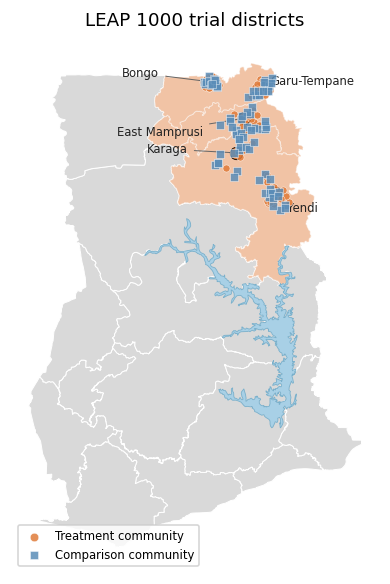

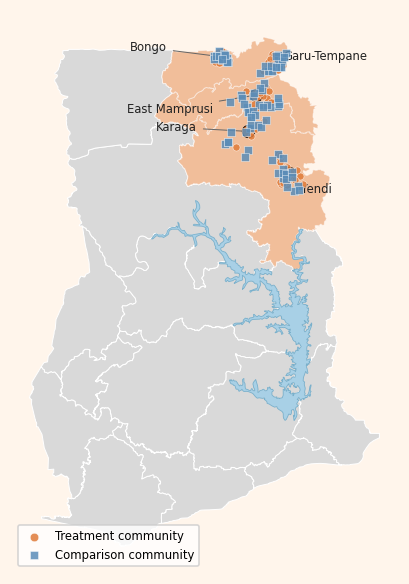

In [2]:
fig, ax = plt.subplots(figsize=(4, 5))
plot_ghana_map(DATA_DIR, ax=ax, df=df)
plt.tight_layout()
plt.show()

# paper-ready version
fig, ax = plt.subplots(figsize=(4, 5))
plot_ghana_map(DATA_DIR, ax=ax, df=df, paper=True)
plt.tight_layout()
fig.savefig(MAP_DIR / 'map.pdf', dpi=150, bbox_inches='tight')
plt.show()

## Sample structure

The panel follows households from baseline (2015) to endline (2017). Household counts can differ across waves due to attrition and survey logistics.

In [3]:
cross = (
    df.groupby(['wave', 'T'])
      .size()
      .unstack('T')
      .rename(index={0: 'Baseline (2015)', 1: 'Endline (2017)'})
      .rename(columns={0: 'Comparison', 1: 'Treatment'})
)
cross['Total'] = cross.sum(axis=1)
cross.loc['Total'] = cross.sum()
cross.astype(int)


T,Comparison,Treatment,Total
wave,,,
Baseline (2015),1235,1262,2497
Endline (2017),1146,1185,2331
Total,2381,2447,4828


## Household characteristics

LEAP 1000 targets the extreme poor in rural northern Ghana. The panels below characterise sample households at baseline and confirm that both arms share similar socioeconomic profiles.

Continuous covariates — baseline means by arm:


,Comparison,Treatment
PMT score,7.23,7.09
Household size,6.30,6.91
Children 0–5,1.87,2.01
Children 6–17,1.62,2.09
Adults 18–64,2.56,2.55
Elderly 65+,0.24,0.26
Head age,38.26,40.37
Rooms,3.33,3.32


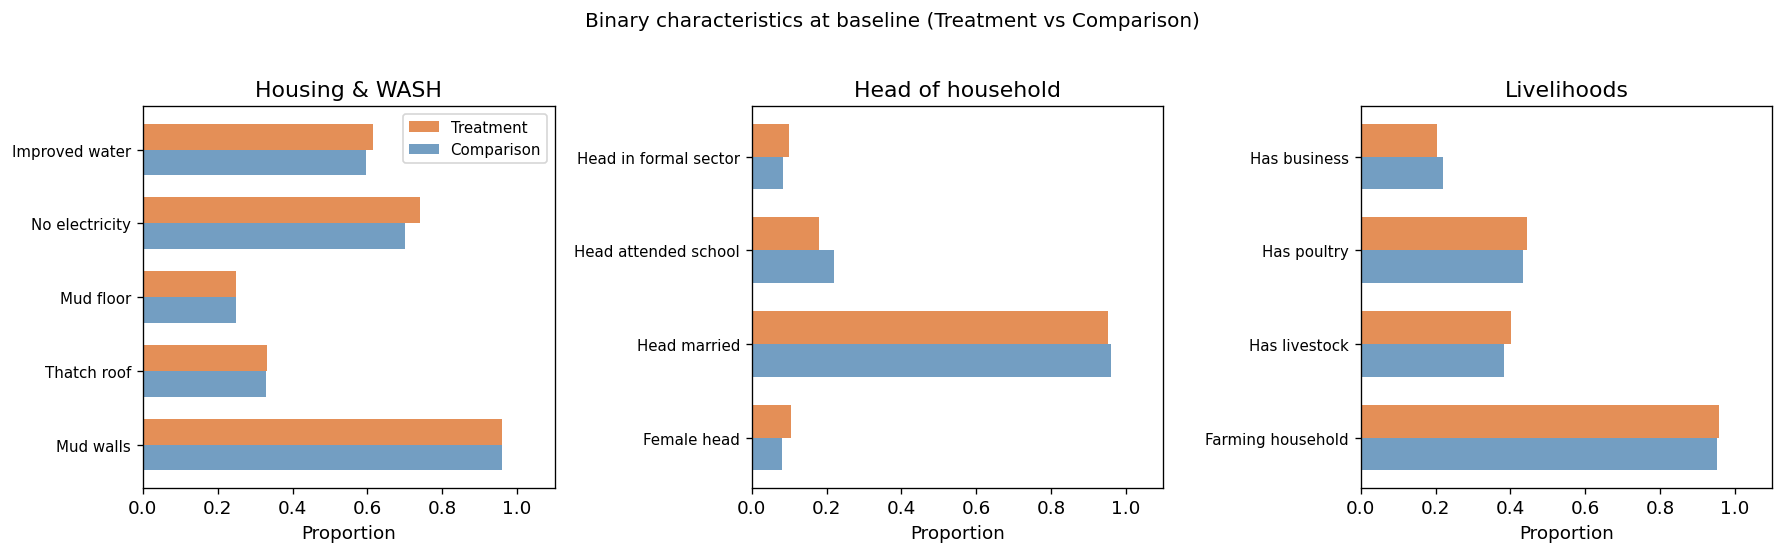

In [4]:
# Continuous covariate means by arm
demo = df0.groupby('T')[NUMERIC_W].mean().round(2)
demo.index = ['Comparison', 'Treatment']
demo.columns = [W_LABELS[c] for c in NUMERIC_W]
print('Continuous covariates — baseline means by arm:')
display(demo.T)

# Binary indicators — three thematic groups
groups = [
    ('Housing & WASH',
     ['mud_walls', 'thatch_roof', 'mud_floor', 'no_electricity', 'improved_water']),
    ('Head of household',
     ['head_female', 'head_married', 'head_schooled', 'head_formal']),
    ('Livelihoods',
     ['farms', 'has_livestock', 'has_poultry', 'has_business']),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (title, cols) in zip(axes, groups):
    labs    = [W_LABELS[c] for c in cols]
    c_means = df0[df0['T'] == 0][cols].mean().values
    t_means = df0[df0['T'] == 1][cols].mean().values
    x, w    = np.arange(len(cols)), 0.35
    ax.barh(x + w/2, t_means, w, color=TREAT_COLOR, alpha=0.85, label='Treatment')
    ax.barh(x - w/2, c_means, w, color=CTRL_COLOR,  alpha=0.85, label='Comparison')
    ax.set_yticks(x)
    ax.set_yticklabels(labs, fontsize=9)
    ax.set_xlim(0, 1.1)
    ax.set_xlabel('Proportion')
    ax.set_title(title)
    if title == 'Housing & WASH':
        ax.legend(fontsize=9)

plt.suptitle('Binary characteristics at baseline (Treatment vs Comparison)',
             y=1.02, fontsize=12)
plt.tight_layout()
plt.show()


## Estimation framework

### What does DiD identify?

With two waves ($t=0$ baseline, $t=1$ endline) and two arms ($T=1$ treatment, $T=0$ comparison), the **Difference-in-Differences** estimator is:

$$
\hat{\delta}_{\text{DiD}}
= \underbrace{(\bar{Y}^{T=1}_1 - \bar{Y}^{T=1}_0)}_{\text{change in treatment arm}}
- \underbrace{(\bar{Y}^{T=0}_1 - \bar{Y}^{T=0}_0)}_{\text{change in comparison arm}}
$$

Subtracting the comparison trend removes time-varying confounders that affect both arms equally.

---

### From DiD to ITT

Under the **parallel trends assumption** — that absent LEAP 1000 both arms would have evolved identically — DiD recovers the **Intent-to-Treat (ITT)** effect:

$$
\delta_{\text{DiD}} = \text{ITT}
= E\bigl[Y_1(1) - Y_1(0) \;\big|\; T_{\text{assigned}} = 1 \bigr]
$$

This is the effect of *being assigned* to a treatment cluster, averaged over all assigned households — including any who did not actually receive a transfer.

---

### ITT vs ATT — why the distinction matters even in an RCT

The cluster-RCT design guarantees **valid random assignment**, but not **perfect receipt**.  After communities are randomised two things can happen:

- **Incomplete take-up**: some households in treatment communities never enrol and receive no transfer ($\pi_c < 1$).
- **Contamination**: some comparison households may indirectly benefit (e.g. through local price or labour-market effects).

Because of these, ITT $\neq$ ATT even in a perfectly randomised trial:

| Estimand | Definition | Identified by DiD? |
|---|---|---|
| **ITT** | Effect of *assignment* to treatment | ✓ directly |
| **ATT** | Effect on households that *received* the transfer | Only if $\pi_c = 1$ |

If $\pi_c$ is the **compliance rate** (share of assigned households that received LEAP 1000), the Bloom (1984) / IV scaling gives:

$$
\text{ATT} \approx \frac{\text{ITT}}{\pi_c}
$$

**Which estimand matters for policy?**  ITT answers "what per-household impact should we expect if we roll out the programme to more communities?" — relevant because real rollouts also have imperfect take-up.  ATT answers "how much did actual recipients benefit?" — relevant for cost-effectiveness.  Both are useful; LEAP 1000 reported ITT as the primary estimate and noted that high compliance made ITT $\approx$ ATT.

---

### Regression formulation

We estimate DiD via OLS:

$$
Y_{it} = \alpha + \beta_1\, T_i + \beta_2\, \text{wave}_t
       + \delta\,(T_i \times \text{wave}_t) + \varepsilon_{it}
$$

| Coefficient | Interpretation |
|---|---|
| $\alpha$ | Comparison arm mean at baseline |
| $\beta_1$ | Baseline arm difference (should be $\approx 0$ under randomisation) |
| $\beta_2$ | Common time trend (comparison arm change) |
| $\delta$ | **DiD = ITT estimate** |

Standard errors are HC1 (heteroscedasticity-robust). Ideally we would cluster at the community level (the randomisation unit), but without community IDs we cluster at the district level — this is conservative (wider CIs) but valid. With only 5 districts, wild cluster bootstrap is preferred for final reporting.

## Outcome variable: adult-equivalent expenditure

`Y` is household consumption expenditure per adult-equivalent per month, deflated to constant Greater Accra August-2017 prices (GH₵). It is the primary welfare measure in the evaluation.

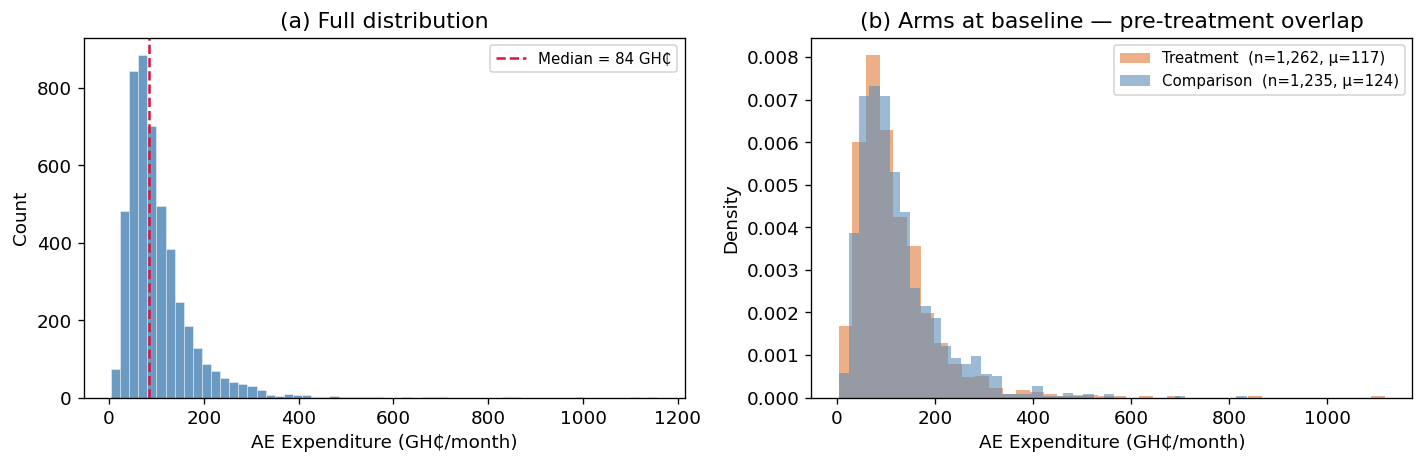

Mean  Median   Std     N
Wave     Arm                                  
Baseline Comparison  123.8   101.5  84.1  1235
         Treatment   117.2    96.2  86.0  1262
Endline  Comparison   84.1    72.8  60.6  1146
         Treatment    85.2    73.0  58.8  1185

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# (a) Full distribution
ax = axes[0]
ax.hist(df['Y'], bins=60, color='steelblue', alpha=0.8, edgecolor='white', lw=0.3)
ax.axvline(df['Y'].median(), color='crimson', lw=1.5, ls='--',
           label=f'Median = {df["Y"].median():.0f} GH₵')
ax.set_xlabel('AE Expenditure (GH₵/month)')
ax.set_ylabel('Count')
ax.set_title('(a) Full distribution')
ax.legend(fontsize=9)

# (b) T vs C at baseline — pre-treatment overlap
ax = axes[1]
for t_val, color, label in [(1, TREAT_COLOR, 'Treatment'), (0, CTRL_COLOR, 'Comparison')]:
    vals = df0[df0['T'] == t_val]['Y']
    ax.hist(vals, bins=40, alpha=0.6, color=color, density=True,
            label=f'{label}  (n={len(vals):,}, μ={vals.mean():.0f})')
ax.set_xlabel('AE Expenditure (GH₵/month)')
ax.set_ylabel('Density')
ax.set_title('(b) Arms at baseline — pre-treatment overlap')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Summary table
tbl = df.groupby(['wave', 'T'])['Y'].agg(['mean', 'median', 'std', 'count'])
tbl.index = tbl.index.set_levels(['Baseline', 'Endline'], level=0)
tbl.index = tbl.index.set_levels(['Comparison', 'Treatment'], level=1)
tbl.index.names = ['Wave', 'Arm']
tbl.columns = ['Mean', 'Median', 'Std', 'N']
tbl.round(1)


## DiD results (ITT estimate)

We start with the naive cell-means DiD for intuition, then move to the OLS formulation which gives standard errors and lets us check baseline balance via $\beta_1$.

In [6]:
print('Naive DiD — cell means (GH₵/month):')
naive_did(df).round(1)


Naive DiD — cell means (GH₵/month):


Arm,Comparison,Treatment,Diff (T−C)
Wave,,,
Baseline,123.8,117.2,-6.6
Endline,84.1,85.2,1.2
DiD,-39.8,-32.0,7.8


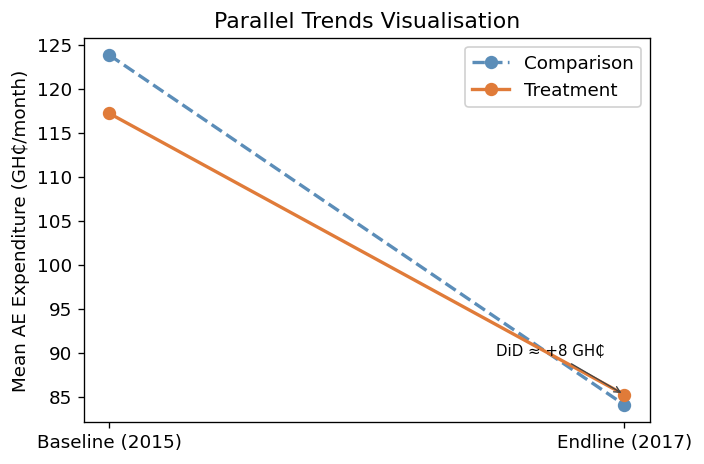

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
plot_parallel_trends(df, ax=ax)
plt.tight_layout()
plt.show()


In [8]:
print('Regression DiD — cluster-robust SEs (clustered by community, G=162):')
display(regression_did(df, cluster='comm').round(2))

print('\nRegression DiD — HC1 SEs (for comparison):')
display(regression_did(df, cluster=None).round(2))

Regression DiD — cluster-robust SEs (clustered by community, G=162):


,Coef,"SE (CRVE, G=162)",t-stat,95% CI lo,95% CI hi
Intercept (C baseline mean),123.85,3.66,33.83,116.68,131.02
T (arm difference at baseline),-6.64,3.15,-2.11,-12.81,-0.46
wave (common time trend),-39.79,4.31,-9.24,-48.23,-31.35
T × wave (DiD = ITT estimate),7.79,3.98,1.96,-0.00,15.59



Regression DiD — HC1 SEs (for comparison):


,Coef,SE (HC1),t-stat,95% CI lo,95% CI hi
Intercept (C baseline mean),123.85,2.39,51.76,119.16,128.54
T (arm difference at baseline),-6.64,3.40,-1.95,-13.31,0.04
wave (common time trend),-39.79,2.99,-13.31,-45.65,-33.93
T × wave (DiD = ITT estimate),7.79,4.21,1.85,-0.46,16.04


## Identification: parallel trends

DiD is valid under the **parallel trends assumption**: absent LEAP 1000, both arms would have experienced the same change in expected expenditure between 2015 and 2017.

With only two survey waves we cannot formally test pre-trends. The main supporting evidence:

1. **Randomisation** — clusters were assigned *before* the baseline survey, so any baseline differences are due to chance, not selection.
2. **Covariate balance** — both arms are well-balanced across all 21 pre-treatment characteristics (see below), consistent with similar pre-treatment trajectories.
3. **Clean baseline** — LEAP 1000 transfers began after the 2015 baseline wave, so baseline outcomes are uncontaminated by treatment.

**Limitation**: we have at most 5 district-level clusters, which constrains the power of balance tests and makes cluster-robust SEs unreliable — wild cluster bootstrap is the preferred method for final inference.

## Covariate balance at baseline

All 21 pre-treatment covariates are tested between arms at baseline.  Two balance flags are reported:

- **p-bal**: Welch t-test p-value > 0.05 — tests statistical significance of the difference.  With n > 1,000 this flag is very sensitive: even trivially small differences can be flagged ✗.
- **smd-bal**: |SMD| < 0.1 — tests *practical* importance of the imbalance, independent of sample size.

Under randomisation most covariates should pass both criteria.  The exception is **PMT score**: all study households are below the poverty eligibility threshold, so the score is compressed into a very narrow range (SD ≈ 0.04).  A tiny absolute difference (−0.138 on a scale of ≈ 7) produces a huge SMD (≈ −3.4) because the denominator is near-zero.  The practical imbalance in PMT score is negligible.

In [9]:
balance_tests(df0, W_ALL, labels=W_LABELS)


,C mean,T mean,Diff (T−C),SMD,p-value,p-bal,smd-bal
variable,,,,,,,
PMT score,7.226,7.088,-0.138,-3.364,0.000,✗,✗
Household size,6.296,6.907,0.611,0.236,0.000,✗,✗
Children 0–5,1.871,2.010,0.138,0.143,0.000,✗,✗
Children 6–17,1.623,2.087,0.464,0.275,0.000,✗,✗
Adults 18–64,2.563,2.552,-0.011,-0.011,0.789,✓,✓
Elderly 65+,0.240,0.259,0.019,0.037,0.349,✓,✓
Head age,38.262,40.369,2.107,0.167,0.000,✗,✗
Rooms,3.332,3.322,-0.010,-0.007,0.867,✓,✓
Head married,0.959,0.951,-0.008,-0.038,0.346,✓,✓


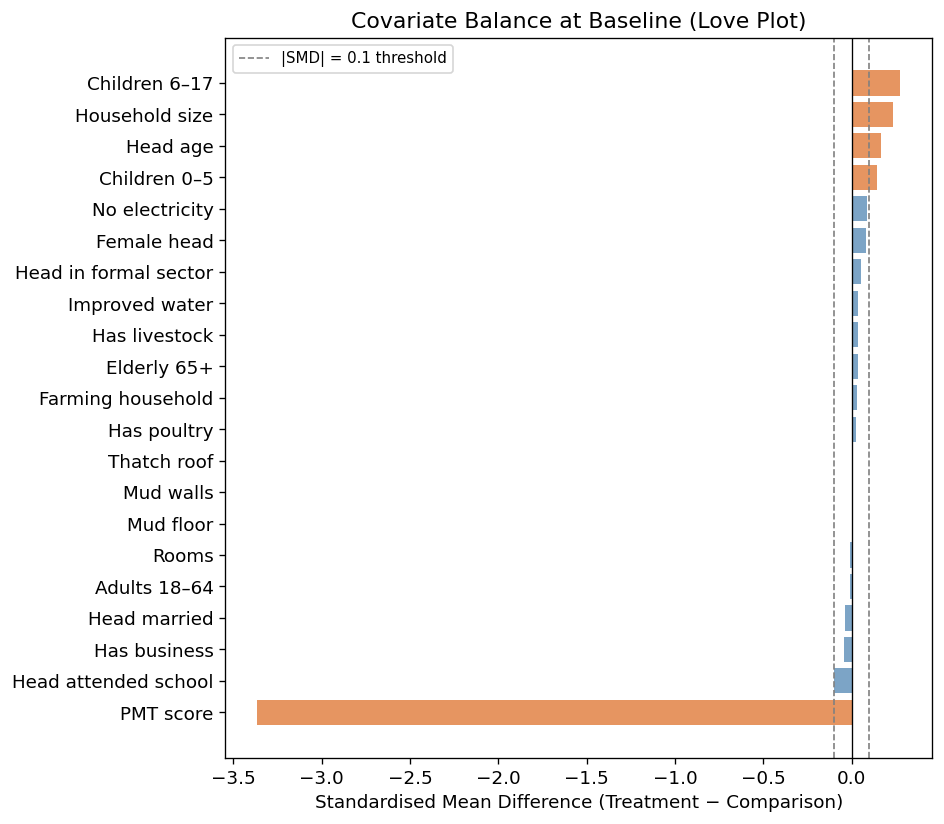

In [10]:
fig, ax = plt.subplots(figsize=(8, 7))
plot_love(df0, W_ALL, labels=W_LABELS, ax=ax)
plt.tight_layout()
plt.show()


## Summary

| Dimension | Finding |
|---|---|
| **Design** | Cluster-RCT in 5 districts; randomisation at community level; 2 waves |
| **Estimand** | DiD identifies ITT; ITT ≈ ATT given high programme compliance (Bloom scaling: ATT = ITT / π_c) |
| **ITT/ATT distinction** | RCT ensures valid assignment, not perfect receipt — incomplete take-up means ITT < ATT even in an RCT |
| **DiD / ITT** | δ̂ = coefficient on T × wave ≈ +7.8 GH₵/month (p ≈ 0.06, marginal significance) |
| **Population** | Eligible extreme rural poor: ~95% mud walls, ~67% no electricity, ~40% female-headed |
| **Balance** | Most covariates balanced on both criteria (|SMD| < 0.1 and p > 0.05). Imbalances in household size and child counts reflect chance variation across clusters. PMT score shows large SMD (≈ −3.4) due to near-zero variance at the poverty threshold — the absolute difference is negligible (0.138 on scale of 7). |
| **Parallel trends** | Cannot be tested with 2 waves; supported by randomisation & balance |
| **SE caveat** | Community-clustered CRVE (G = 162) reported as primary; HC1 shown for comparison. Wild cluster bootstrap still recommended for final inference given uncertainty about the exact randomisation unit. |